In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [75]:
df = pd.read_excel("Python examination.xlsx")

In [76]:
pd.set_option('display.max_columns', None)

In [77]:
#Display first 10 column

df.head(10)

,customer,gender,count of transactions,average day interval between atm transactions,current balance,median of cash transactions,phone,Bought
0,1,NaN,296,3,10618,289,NaN,1
1,2,NaN,0,0,483,0,NaN,1
2,3,M,189,2,7031,1408,ANDROID,1
3,4,NaN,3572,25,,711,ANDROID,1
4,5,NaN,228,3,6680,0,ANDROID,1
5,6,NaN,17,2,1036,0,NaN,1
6,7,M,500,4,8194,749,ANDROID,1
7,8,NaN,477,2,6777,0,ANDROID,1
8,9,M,125,3,476,0,NaN,1
9,10,NaN,108,3,4,0,NaN,1


In [78]:
#Get general information(null, data types) from dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   customer                                       313 non-null    int64 
 1   gender                                         274 non-null    object
 2   count of transactions                          313 non-null    int64 
 3   average day interval between atm transactions  313 non-null    int64 
 4   current balance                                313 non-null    object
 5   median of cash transactions                    313 non-null    int64 
 6   phone                                          240 non-null    object
 7   Bought                                         313 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 19.7+ KB


In [79]:
#Get shape of dataset(8 column, 313 rows)

df.shape

(313, 8)

In [80]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer,313.0,157.000000,90.499540,1.0,79.0,157.0,235.0,313.0
count of transactions,313.0,1251.600639,4773.343986,0.0,53.0,309.0,699.0,46463.0
average day interval between atm transactions,313.0,8.565495,29.069375,0.0,2.0,3.0,5.0,300.0
median of cash transactions,313.0,287.396166,437.632064,0.0,0.0,73.0,420.0,2361.0
Bought,313.0,0.210863,0.408574,0.0,0.0,0.0,0.0,1.0


In [81]:
#Check sum of null values for per columns

df.isnull().sum()

,0
customer,0
gender,39
count of transactions,0
average day interval between atm transactions,0
current balance,0
median of cash transactions,0
phone,73
Bought,0


In [82]:
##Check sum of null values for per columns with percent


df.isnull().sum() / len(df) * 100

,0
customer,0.000000
gender,12.460064
count of transactions,0.000000
average day interval between atm transactions,0.000000
current balance,0.000000
median of cash transactions,0.000000
phone,23.322684
Bought,0.000000


In [83]:
#Check duplicated values

df.duplicated().sum()

np.int64(0)

In [84]:
#Delete irrelvant column(ID columns(all of them are same))

df.drop(columns=['customer'], inplace=True)

In [85]:
df.head(5)

,gender,count of transactions,average day interval between atm transactions,current balance,median of cash transactions,phone,Bought
0,NaN,296,3,10618,289,NaN,1
1,NaN,0,0,483,0,NaN,1
2,M,189,2,7031,1408,ANDROID,1
3,NaN,3572,25,,711,ANDROID,1
4,NaN,228,3,6680,0,ANDROID,1


In [86]:
#Check outliers with IQR method (less than 25 % and more than 75 % values are outliers)

numeric_df = df.select_dtypes(include='number')

columns_with_outliers = []

for col in numeric_df:

  if col != 'Bought':
      Q1 = numeric_df[col].quantile(0.25)
      Q3 = numeric_df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower = Q1 - 1.5 * IQR
      upper = Q3 + 1.5 * IQR

      if ((numeric_df[col] < lower) | (numeric_df[col] > upper)).any():
            columns_with_outliers.append(col)

print("Columns with outliers:", columns_with_outliers )



Columns with outliers: ['count of transactions', 'average day interval between atm transactions', 'median of cash transactions']


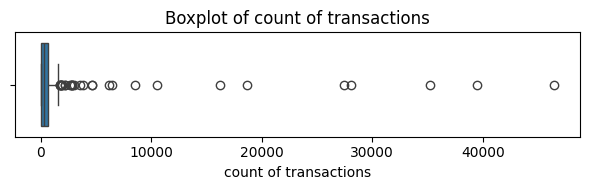

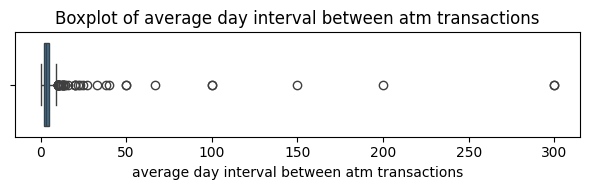

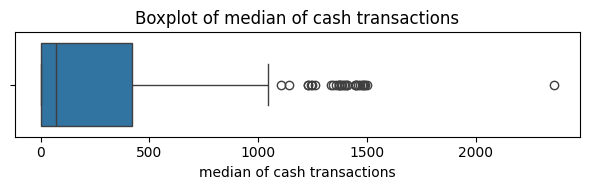

In [87]:
#Visualization outliers with boxplot(again less than 25 % and more than 75 % values are outliers(we can check with boxplots))

import seaborn as sns

numeric_columns = df.select_dtypes(include='number')

for col in numeric_columns:
  if col != 'Bought':
    plt.figure(figsize=(6, 2))
    sns.boxplot(data=numeric_df[col], orient='h')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [88]:
# Calculate skewness for each numerical column

numeric_columns = df.select_dtypes(include='number').columns
skewness = df[numeric_columns].skew()
print("Skewness of the dataset:")
print(skewness)

Skewness of the dataset:
count of transactions                            6.963833
average day interval between atm transactions    8.043105
median of cash transactions                      1.801088
Bought                                           1.424450
dtype: float64


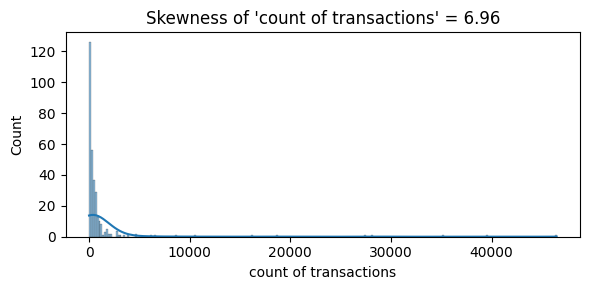

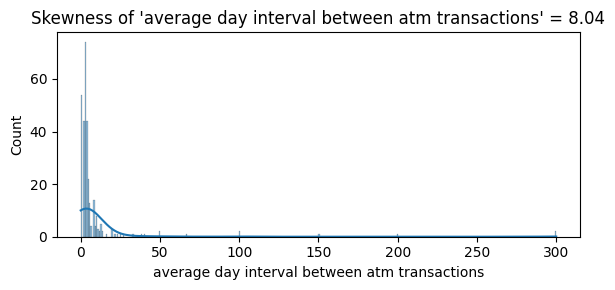

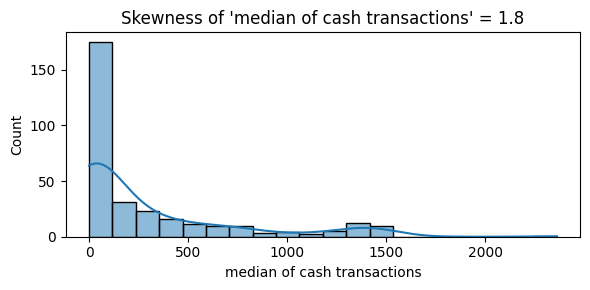

In [89]:
#Print skewness with plot (Histplot)

for col in numeric_columns:

   if col != 'Bought':
        plt.figure(figsize=(6, 3))
        sns.histplot(df[col], kde=True)
        skewness = df[col].skew()
        plt.title(f"Skewness of '{col}' = {round(skewness, 2)}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


In [90]:
#Solve outliers problems with clip values methods

for col in columns_with_outliers:
  if col != 'Bought':
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Clip values outside bounds
    df[col] = np.clip(df[col], lower, upper)

In [91]:
#Again check outliers after solve wiht clip values methods

numeric_df = df.select_dtypes(include='number')

columns_with_outliers = []

for col in numeric_df:

  if col != 'Bought':
      Q1 = numeric_df[col].quantile(0.25)
      Q3 = numeric_df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower = Q1 - 1.5 * IQR
      upper = Q3 + 1.5 * IQR

      if ((numeric_df[col] < lower) | (numeric_df[col] > upper)).any():
            columns_with_outliers.append(col)

print("Columns with outliers:", columns_with_outliers )

Columns with outliers: []


In [92]:
df.head(5)

,gender,count of transactions,average day interval between atm transactions,current balance,median of cash transactions,phone,Bought
0,NaN,296,3.0,10618,289,NaN,1
1,NaN,0,0.0,483,0,NaN,1
2,M,189,2.0,7031,1050,ANDROID,1
3,NaN,1668,9.5,,711,ANDROID,1
4,NaN,228,3.0,6680,0,ANDROID,1


In [93]:
#Again check outliers

df.isnull().sum()

,0
gender,39
count of transactions,0
average day interval between atm transactions,0
current balance,0
median of cash transactions,0
phone,73
Bought,0


In [94]:
#We have some columns which they have some empty rows so we have to fill with values(np.nan)

df = df.replace(' ', np.nan)

<ipython-input-94-fc852012f718>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(' ', np.nan)


In [95]:
#After fill np.nan process, fill null values with SimpleImputer(It is suitable for small datasets)

from sklearn.impute import SimpleImputer

df_categorical = df.select_dtypes(include='object').columns

imputer_categorical = SimpleImputer(strategy='most_frequent')
imputer_categorical.fit(df[df_categorical])

df[df_categorical] = imputer_categorical.transform(df[df_categorical])

In [96]:


df.isnull().sum()

,0
gender,0
count of transactions,0
average day interval between atm transactions,0
current balance,7
median of cash transactions,0
phone,0
Bought,0


In [97]:
#Change type of "current balance" type instead of dataseries with dataframe

from sklearn.impute import SimpleImputer

# Reshape 'current balance' to a 2D array
current_balance_2d = df[['current balance']]  # Double brackets to select as DataFrame

imputer_categorical = SimpleImputer(strategy='median')
imputer_categorical.fit(current_balance_2d)  # Fit on the 2D array

df['current balance'] = imputer_categorical.transform(current_balance_2d)

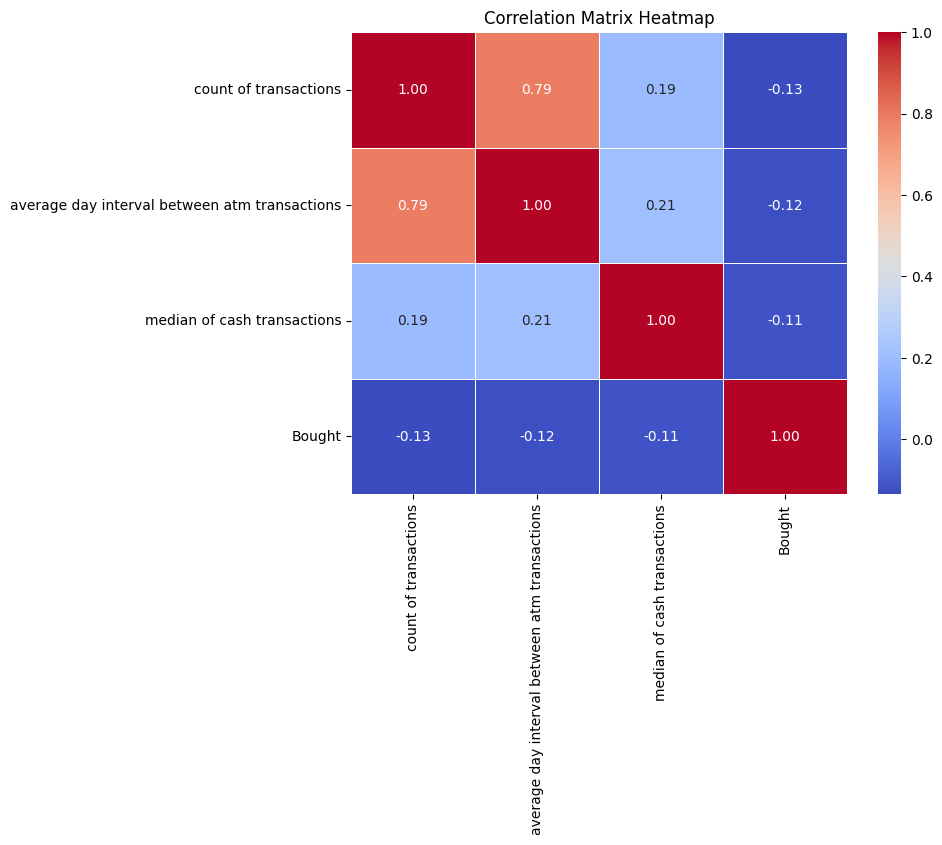

In [98]:
# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [99]:
#Scale all numerical expect 'Bought'(because of target)
#StandardScaler is suitable for data which clean form outliers

from sklearn.preprocessing import StandardScaler

numeric_columns = df.select_dtypes(include='number').columns.drop('Bought')

scalar1 = StandardScaler()

df[numeric_columns] = scalar1.fit_transform(df[numeric_columns])

In [100]:

df.head(5)

,gender,count of transactions,average day interval between atm transactions,current balance,median of cash transactions,phone,Bought
0,M,-0.340015,-0.313289,-0.042227,0.100925,IOS,1
1,M,-0.913034,-1.324212,-0.099056,-0.724961,IOS,1
2,M,-0.547153,-0.650264,-0.062340,2.275660,ANDROID,1
3,M,2.316004,1.877044,-0.093659,1.306888,ANDROID,1
4,M,-0.471654,-0.313289,-0.064308,-0.724961,ANDROID,1


In [101]:
# 'count of transactions' and 'average day interval between atm transactions' have high correlation so we have to apply pca. After we create 1 feature with 2 columns which they have high correlation


from sklearn.decomposition import PCA

df_selected_pca = df[['count of transactions', 'average day interval between atm transactions']]

pca = PCA(n_components=1)
pca_components = pca.fit_transform(df_selected_pca)

df['PCA_component'] = pca_components

df.head(5)


,gender,count of transactions,average day interval between atm transactions,current balance,median of cash transactions,phone,Bought,PCA_component
0,M,-0.340015,-0.313289,-0.042227,0.100925,IOS,1,-0.461956
1,M,-0.913034,-1.324212,-0.099056,-0.724961,IOS,1,-1.581972
2,M,-0.547153,-0.650264,-0.062340,2.275660,ANDROID,1,-0.846702
3,M,2.316004,1.877044,-0.093659,1.306888,ANDROID,1,2.964933
4,M,-0.471654,-0.313289,-0.064308,-0.724961,ANDROID,1,-0.555039


In [102]:
#After pca we drop last 2 columns from dataset

df = df.drop(columns=['count of transactions', 'average day interval between atm transactions'])


In [103]:
df.head(5)

,gender,current balance,median of cash transactions,phone,Bought,PCA_component
0,M,-0.042227,0.100925,IOS,1,-0.461956
1,M,-0.099056,-0.724961,IOS,1,-1.581972
2,M,-0.062340,2.275660,ANDROID,1,-0.846702
3,M,-0.093659,1.306888,ANDROID,1,2.964933
4,M,-0.064308,-0.724961,ANDROID,1,-0.555039


In [104]:
#As result all columns without null values

df.isnull().sum()

,0
gender,0
current balance,0
median of cash transactions,0
phone,0
Bought,0
PCA_component,0


In [105]:
df['gender'] = df['gender'].apply(lambda x: 1 if x == 'M' else 0)
df['phone'] = df['phone'].apply(lambda  x: 1 if x== 'IOS' else 0)

In [106]:
df.nunique()

,0
gender,2
current balance,244
median of cash transactions,134
phone,2
Bought,2
PCA_component,223


In [107]:
df.head()

,gender,current balance,median of cash transactions,phone,Bought,PCA_component
0,1,-0.042227,0.100925,1,1,-0.461956
1,1,-0.099056,-0.724961,1,1,-1.581972
2,1,-0.062340,2.275660,0,1,-0.846702
3,1,-0.093659,1.306888,0,1,2.964933
4,1,-0.064308,-0.724961,0,1,-0.555039


In [113]:
#Divided data 2 parts: Independent columns(X) and target column(y)

X = df.drop('Bought', axis=1).values
y = df['Bought'].values

In [114]:
#Check imbalanced problems at 'target' column

df['Bought'].value_counts()

,count
Bought,
0,247
1,66


In [115]:
#Solve imbalanced dataset problem  with  RandomOverSampler because, our dataset is small so oversample is better than other methods

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

In [116]:
target_distribution_resampled = pd.Series(y_res).value_counts()

# Print the new distribution
print(target_distribution_resampled)

1    247
0    247
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66        49
           1       0.67      0.64      0.65        50

    accuracy                           0.66        99
   macro avg       0.66      0.66      0.66        99
weighted avg       0.66      0.66      0.66        99



In [ ]:
from sklearn.metrics import accuracy_score

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6566


In [ ]:
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier from sklearn.ensemble
from sklearn.metrics import classification_report # Import classification_report from sklearn.metrics
from sklearn.metrics import accuracy_score # Import accuracy_score from sklearn.metrics


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        49
           1       0.91      1.00      0.95        50

    accuracy                           0.95        99
   macro avg       0.95      0.95      0.95        99
weighted avg       0.95      0.95      0.95        99



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9494949494949495

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Initialize different models such as 'Logistic Regression', 'SVM' and ext
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    results[model_name] = {'accuracy': accuracy}

results


{'Logistic Regression': {'accuracy': 0.6565656565656566},
 'SVM': {'accuracy': 0.7070707070707071},
 'K-Nearest Neighbors': {'accuracy': 0.6464646464646465},
 'Decision Tree': {'accuracy': 0.9292929292929293},
 'Gradient Boosting': {'accuracy': 0.8686868686868687}}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
report_logreg = classification_report(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy_logreg)
print("Classification Report:\n", report_logreg)

Logistic Regression Accuracy: 0.6565656565656566
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        49
           1       0.91      1.00      0.95        50

    accuracy                           0.95        99
   macro avg       0.95      0.95      0.95        99
weighted avg       0.95      0.95      0.95        99



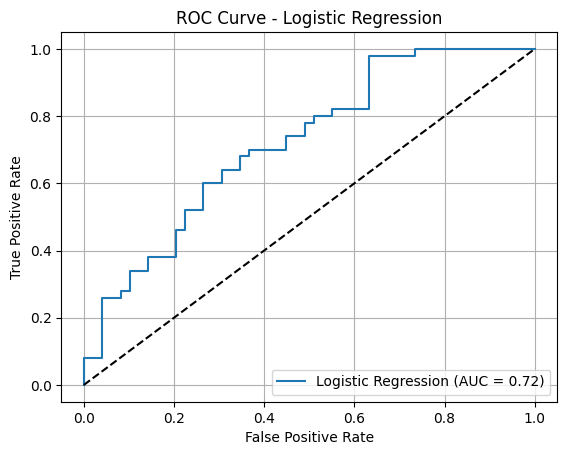

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, RocCurveDisplay


# ROC-AUC
if len(set(y_test)) == 2:  # Binary classification check
    y_proba = logreg.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Logistic Regression')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()
else:
    print("ROC-AUC not supported for multi-class without binarization.")

In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)


print("SVM Accuracy:", accuracy_svm)
print("Classification Report:\n", report_svm)

SVM Accuracy: 0.7070707070707071
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.69      0.70        49
           1       0.71      0.72      0.71        50

    accuracy                           0.71        99
   macro avg       0.71      0.71      0.71        99
weighted avg       0.71      0.71      0.71        99



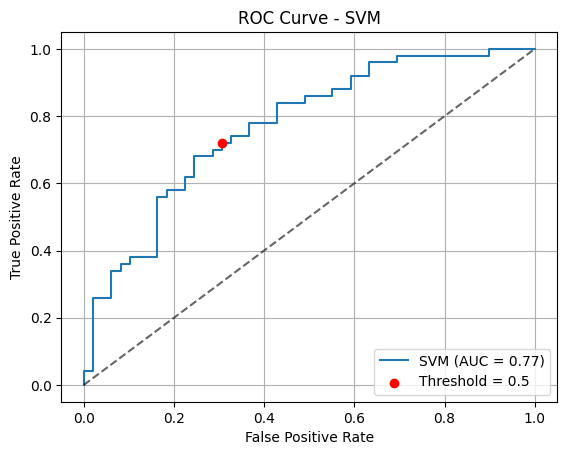

In [ ]:
# ROC-AUC visualization
if len(set(y_test)) == 2:
    y_proba_svm = svm.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_svm)
    roc_auc = auc(fpr, tpr)

    # Calculate point at threshold=0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()
    point_fpr = fp / (fp + tn)
    point_tpr = tp / (tp + fn)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.scatter(point_fpr, point_tpr, color='red', label='Threshold = 0.5', zorder=10)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - SVM')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("ROC-AUC not supported for multi-class without binarization.")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred)
report_knn = classification_report(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("Classification Report:\n", report_knn)

KNN Accuracy: 0.9494949494949495
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.69      0.66        49
           1       0.67      0.60      0.63        50

    accuracy                           0.65        99
   macro avg       0.65      0.65      0.65        99
weighted avg       0.65      0.65      0.65        99



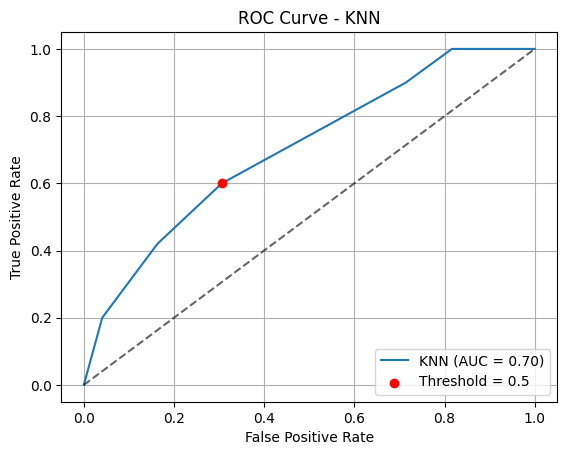

In [ ]:
if len(set(y_test)) == 2:  # Binary classification
    y_proba_knn = knn.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_knn)
    roc_auc = auc(fpr, tpr)

    # Point at threshold 0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel()
    point_fpr = fp / (fp + tn)
    point_tpr = tp / (tp + fn)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.scatter(point_fpr, point_tpr, color='red', label='Threshold = 0.5', zorder=10)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - KNN')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("ROC-AUC not supported for multi-class without binarization.")

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Classification Report:\n", report_dt)


Decision Tree Accuracy: 0.9292929292929293
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92        49
           1       0.88      1.00      0.93        50

    accuracy                           0.93        99
   macro avg       0.94      0.93      0.93        99
weighted avg       0.94      0.93      0.93        99



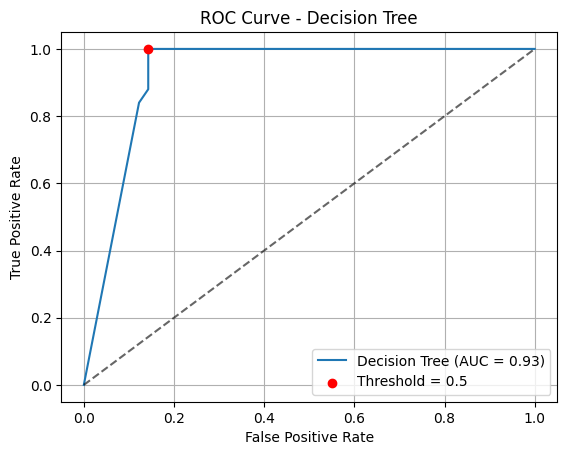

In [ ]:
if len(set(y_test)) == 2:  # Binary classification
    y_proba_dt = dt.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
    roc_auc = auc(fpr, tpr)

    # Calculate point at threshold=0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
    point_fpr = fp / (fp + tn)
    point_tpr = tp / (tp + fn)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.scatter(point_fpr, point_tpr, color='red', label='Threshold = 0.5', zorder=10)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Decision Tree')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("ROC-AUC not supported for multi-class without binarization.")

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Classification Report:\n", report_gb)

Gradient Boosting Accuracy: 0.8686868686868687
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86        49
           1       0.84      0.92      0.88        50

    accuracy                           0.87        99
   macro avg       0.87      0.87      0.87        99
weighted avg       0.87      0.87      0.87        99



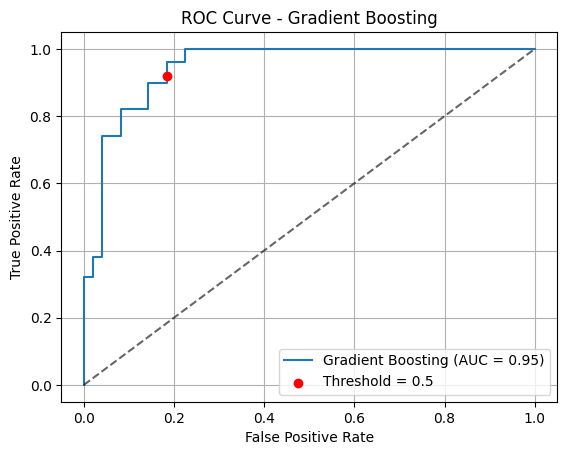

In [ ]:
if len(set(y_test)) == 2:  # Binary classification
    y_proba_gb = gb.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_gb)
    roc_auc = auc(fpr, tpr)

    # Point at threshold 0.5
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gb).ravel()
    point_fpr = fp / (fp + tn)
    point_tpr = tp / (tp + fn)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.scatter(point_fpr, point_tpr, color='red', label='Threshold = 0.5', zorder=10)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Gradient Boosting')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("ROC-AUC not supported for multi-class without binarization.")


In [ ]:
from sklearn.ensemble import StackingClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


#Three advanced ML models:
#1.Stacking model
#2.Voting Classifier (Hard Voting)
#3.Boosting model

# Base models for stacking
base_learners = [
    ('logreg', LogisticRegression(random_state=42)),
    ('svc', SVC(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# Meta-model for stacking
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())

#Voting Classifier (Hard Voting)
voting_model = VotingClassifier(estimators=base_learners, voting='hard')

# Boosting model
boosting_model = GradientBoostingClassifier(random_state=42)

# Train and evaluate each model
models = {
    'Stacking Classifier': stacking_model,
    'Voting Classifier': voting_model,
    'Gradient Boosting': boosting_model
}


results = {}
for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred)

    results[model_name] = {'accuracy': accuracy}

results


{'Stacking Classifier': {'accuracy': 0.9292929292929293},
 'Voting Classifier': {'accuracy': 0.7171717171717171},
 'Gradient Boosting': {'accuracy': 0.8686868686868687}}

In [ ]:
from sklearn.ensemble import StackingClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

base_learners = [
    ('logreg', LogisticRegression(random_state=42)),
    ('svc', SVC(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())

voting_model = VotingClassifier(estimators=base_learners, voting='hard')

boosting_model = GradientBoostingClassifier(random_state=42)

models = {
    'Stacking Classifier': stacking_model,
    'Voting Classifier': voting_model,
    'Gradient Boosting': boosting_model
}

results = {}
for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)

    accuracy_train = accuracy_score(y_train, y_pred_train)

    report_train = classification_report(y_train, y_pred_train)

    results[model_name] = {'accuracy_train': accuracy_train}

results


{'Stacking Classifier': {'accuracy_train': 0.979746835443038},
 'Voting Classifier': {'accuracy_train': 0.8405063291139241},
 'Gradient Boosting': {'accuracy_train': 0.9392405063291139}}